In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'serif'

from astropy.io import fits
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo
from astropy.visualization import simple_norm
from astropy.modeling.fitting import LevMarLSQFitter
from astropy.modeling.models import Const2D, Gaussian2D
from astropy.stats import sigma_clipped_stats, SigmaClip, mad_std
import astropy.coordinates as coord
from astropy.wcs import WCS
from astropy.wcs import utils
from astropy.time import Time

from photutils.aperture import ApertureStats, CircularAperture, CircularAnnulus, RectangularAperture, aperture_photometry
from photutils.background import MMMBackground,SExtractorBackground,Background2D
from photutils.utils import calc_total_error
from astropy.coordinates import SkyCoord

from datetime import datetime
from astropy.coordinates import EarthLocation, AltAz, get_body

from matplotlib.lines import Line2D

c:\Users\lunal\miniconda3\envs\astro\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from pathlib import Path
directory = Path(r"...") 

In [3]:
targets = []

tolerance = 30 * u.arcsec

for file in sorted(os.listdir(directory)):
    if file.endswith(".fits"):
        filepath = os.path.join(directory, file)
        header = fits.getheader(filepath, 0)

        tech = header["HIERARCH ESO DPR TECH"]
        if tech != "POLARIMETRY":
            continue

        date_obs = header["DATE-OBS"]
        if not (date_obs.startswith("2021-01-26") or date_obs.startswith("2021-01-27")):
            continue

        ra = header["RA"]
        dec = header["DEC"]
        obs_name = header.get("HIERARCH ESO OBS NAME", "ukendt")
        filt = header.get("HIERARCH ESO INS FILT1 NAME", "ukendt")

        coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)

        found_target = False

        for target in targets:
            separation = coord.separation(target["coord"])

            if separation < tolerance:
                target["files"].append({
                    "file": file,
                    "filter": filt,
                })
                found_target = True
                break

        if not found_target:
            targets.append({
                "coord": coord,
                "obs_name": obs_name,
                "files": [
                    {
                        "file": file,
                        "filter": filt,
                    }
                ],
            })

print("Antal targets fundet:", len(targets))

Antal targets fundet: 14


In [4]:
filtered_targets = []

wanted_filter = "b_HIGH"

for target in targets:
    files_in_filter = [
        item for item in target["files"]
        if item["filter"] == wanted_filter
    ]

    if files_in_filter:
        filtered_targets.append({
            "coord": target["coord"],
            "obs_name": target["obs_name"],
            "files": files_in_filter,
        })

print("Antal targets i filter", wanted_filter, ":", len(filtered_targets))

Antal targets i filter b_HIGH : 14


In [ ]:
def get_moon_pos(t):

    location = EarthLocation(
        lat=-24.627 * u.deg,
        lon=-70.404 * u.deg,
        height=2635 * u.m
    )

    altaz_frame = AltAz(obstime=t, location=location)
    moon = get_body("moon", t, location)
    moon_altaz = moon.transform_to(altaz_frame)

    

    return moon_altaz.alt.deg, moon_altaz.az.deg

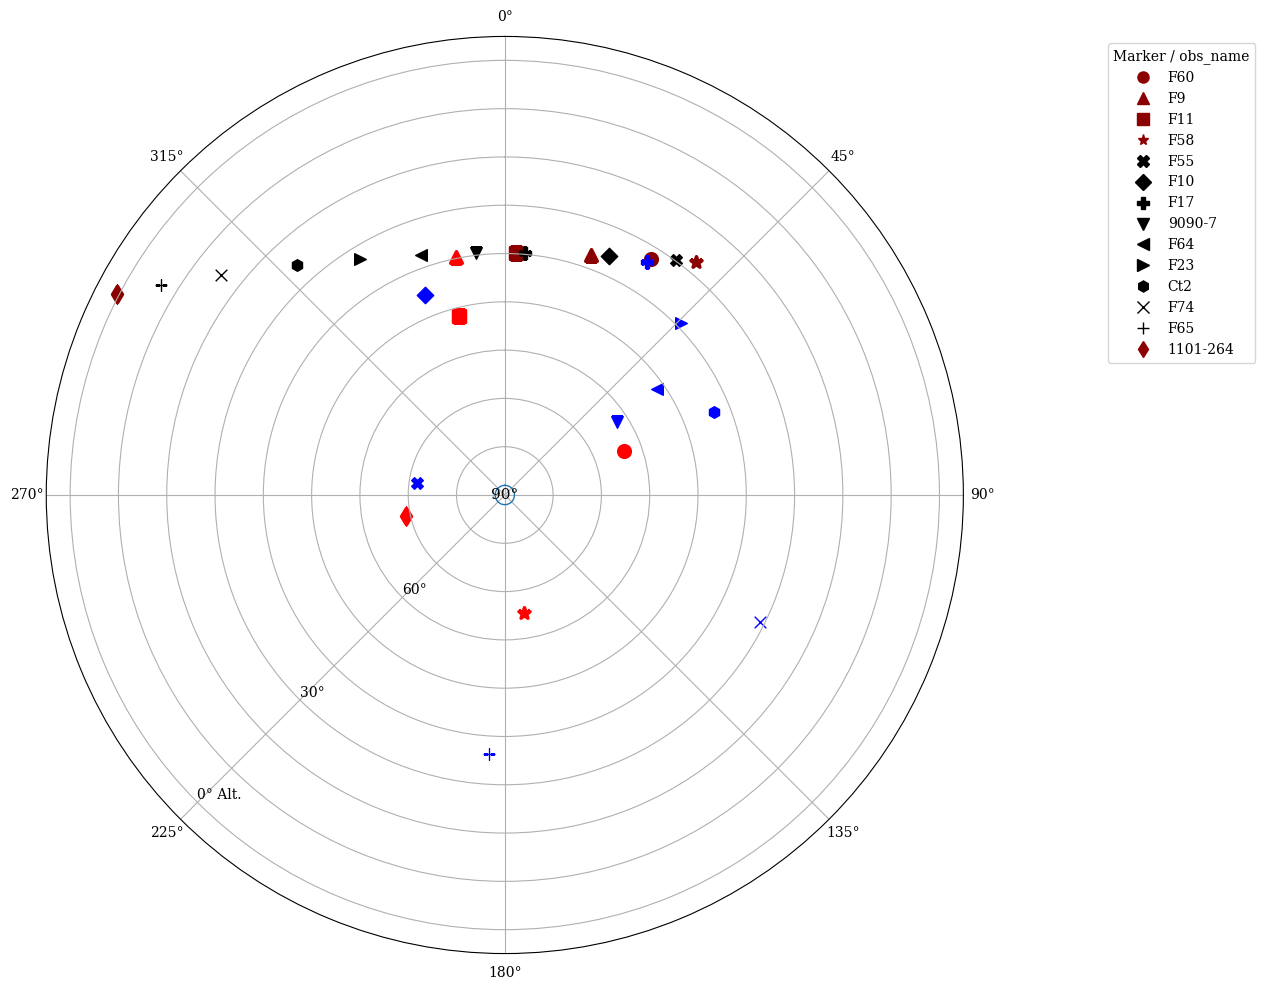

In [ ]:
wanted_filter = "b_HIGH"

moon_alt = []
moon_az = []
field_alt = []
field_az = []
obs_names = []

vlt = EarthLocation(
    lat=-24.627 * u.deg,
    lon=-70.404 * u.deg,
    height=2635 * u.m
)

for target in targets:
    matching_files = [f for f in target["files"] if f["filter"] == wanted_filter]

    if not matching_files:
        continue

    first_file = matching_files[0]["file"]
    filepath = os.path.join(directory, first_file)

    header = fits.getheader(filepath, 0)
    t = Time(header["DATE-OBS"])

    
    alt_moon, az_moon = get_moon_pos(t)
    moon_alt.append(alt_moon)
    moon_az.append(az_moon)

    
    altaz_frame = AltAz(obstime=t, location=vlt)
    coord_altaz = target["coord"].transform_to(altaz_frame)
    field_alt.append(coord_altaz.alt.deg)
    field_az.append(coord_altaz.az.deg)

    
    obs_names.append(target["obs_name"])

theta_moon = np.deg2rad(np.array(moon_az))
r_moon = 90 - np.array(moon_alt)

theta_field = np.deg2rad(np.array(field_az))
r_field = 90 - np.array(field_alt)

markers = ['o', '^', 's', '*', 'X', 'D', 'P', 'v', '<', '>', 'h', 'x', '+', 'd']

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(12, 10))

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rticks(np.arange(0, 91, 10))
ax.set_yticklabels([
    '', '', '', '60°', '', '', '30°', '', '', '0° Alt.'
])
ax.set_rlabel_position(225)
theta = np.linspace(0, 2*np.pi, 500)
ax.plot(theta, np.full_like(theta, 2), linewidth=1)
ax.text(0, 0, '90°', ha='center', va='center', fontsize=11)

legend_handles = []
special_fields = ["F60", "F9", "F11", "F58", "1101-264"]

for i, (tm, rm, tf, rf, name) in enumerate(
    zip(theta_moon, r_moon, theta_field, r_field, obs_names)):
    m = markers[i % len(markers)]

    if name in special_fields:
        moon_color = "darkred"
        field_color ="red"
        size=70
        lw=2.5
    else: 
        moon_color="black"
        field_color="blue"
        size=70
        lw=1

    ax.scatter(tm, rm, color=moon_color, marker=m, s=size, linewidths=lw)
    ax.scatter(tf, rf, color=field_color, marker=m, s=size, linewidths=lw)

    if name in special_fields:
        legend_color = "darkred"
    else:
        legend_color = "black"
        
    legend_handles.append(
        Line2D(
        [0], [0],
        marker=m,
        color=legend_color,
        linestyle='None',
        markersize=8,
        label=str(name)
    )
)

ax.legend(
    handles=legend_handles,
    title=f'Marker / obs_name',
    bbox_to_anchor=(1.15, 1.0),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [7]:
wanted_filter = "b_HIGH"

moon_alt = []
moon_az = []
field_alt = []
field_az = []
obs_names = []

vlt = EarthLocation(
    lat=-24.627 * u.deg,
    lon=-70.404 * u.deg,
    height=2635 * u.m
)

for target in targets:
    matching_files = [f for f in target["files"] if f["filter"] == wanted_filter]

    if not matching_files:
        continue

    first_file = matching_files[0]["file"]
    filepath = os.path.join(directory, first_file)

    header = fits.getheader(filepath, 0)
    t = Time(header["DATE-OBS"])

    alt_moon, az_moon = get_moon_pos(t)
    moon_alt.append(alt_moon)
    moon_az.append(az_moon)

    altaz_frame = AltAz(obstime=t, location=vlt)
    coord_altaz = target["coord"].transform_to(altaz_frame)
    field_alt.append(coord_altaz.alt.deg)
    field_az.append(coord_altaz.az.deg)

    obs_names.append(target["obs_name"])

separations = []

for name, alt_m, az_m, alt_f, az_f in zip(obs_names, moon_alt, moon_az, field_alt, field_az):
    moon_coord = SkyCoord(alt=alt_m * u.deg, az=az_m * u.deg, frame=AltAz())
    field_coord = SkyCoord(alt=alt_f * u.deg, az=az_f * u.deg, frame=AltAz())

    sep = moon_coord.separation(field_coord)
    separations.append((name, sep))

for name, sep in separations:
    print(f"{name}: {sep.deg:.3f} grader")

F60: 39.124 grader
F9: 24.498 grader
F11: 16.541 grader
F58: 79.799 grader
F55: 69.930 grader
F10: 35.145 grader
F17: 22.178 grader
9090-7: 43.736 grader
F64: 52.427 grader
F23: 60.957 grader
Ct2: 86.130 grader
F74: 132.328 grader
F65: 107.851 grader
1101-264: 74.416 grader


In [8]:
obs_names = [target["obs_name"] for target in targets]

separations = []

for name, alt_m, az_m, alt_f, az_f in zip(obs_names, moon_alt, moon_az, field_alt, field_az):
    moon_coord = SkyCoord(alt=alt_m * u.deg, az=az_m * u.deg, frame=AltAz())
    field_coord = SkyCoord(alt=alt_f * u.deg, az=az_f * u.deg, frame=AltAz())

    sep = moon_coord.separation(field_coord)
    separations.append((name, sep))

for name, sep in separations:
    print(f"{name}: {sep.deg:.3f} grader")

F60: 39.124 grader
F9: 24.498 grader
F11: 16.541 grader
F58: 79.799 grader
F55: 69.930 grader
F10: 35.145 grader
F17: 22.178 grader
9090-7: 43.736 grader
F64: 52.427 grader
F23: 60.957 grader
Ct2: 86.130 grader
F74: 132.328 grader
F65: 107.851 grader
1101-264: 74.416 grader
